# Data Information

This dataset contains medical insurance cost information for 1338 individuals. It includes demographic and health-related variables such as age, sex, BMI, number of children, smoking status, and residential region in the US. The target variable is charges, which represents the medical insurance cost billed to the individual.

Source: https://doi.org/10.34740/kaggle/dsv/12853160

# Dataset

In [644]:
import pandas as pd

data_df = pd.read_csv("insurance.csv")
data_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


# Problem Definition

## Objective

- use the dataset to estimate insurance bill/cost per person
- identify which variables are most associated with higher or lower insurance bill

## Usecase

Corporate Wellness Program
- Identify high-risk employees based on predicted healthcare costs
- Enable targeted interventions to reduce the company’s overall healthcare expenses

Insurance Company
- Analyze healthcare cost trends across different population segments
- Enable dynamic premium pricing based on individual risk profiles
- Provide personalized insurance plans tailored to each customer

Example Use Case
A person with certain conditions who is predicted to have high healthcare costs can be recommended lifestyle interventions

# 1. Data Preparation

## 1.1 Data Understanding

In [645]:
print("Shape:", data_df.shape)

Shape: (1338, 7)


In [646]:
print("Columns:", data_df.columns)

Columns: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


In [647]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [648]:
data_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [649]:
data_df.duplicated().sum()

np.int64(1)

In [650]:
data_df = data_df.drop_duplicates()
data_df.duplicated().sum()

np.int64(0)

In [651]:
data_df.describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [652]:
data_df.describe(include="str")

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


# 2. Data Cleaning

## 2.1 Outlier 

In [653]:
num_cols = ['age', 'bmi', 'charges']

print(f"from data_df")
for col in num_cols:
    Q1 = data_df[col].quantile(0.25)
    Q3 = data_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data_df[(data_df[col] < lower) | (data_df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

from data_df
age: 0 outliers
bmi: 9 outliers
charges: 139 outliers


In [654]:
Q1 = data_df['bmi'].quantile(0.25)
Q3 = data_df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(data_df)
data_df = data_df[(data_df['bmi'] >= lower) & (data_df['bmi'] <= upper)]
after = len(data_df)

print(f"from data_df")
print(f"Dropped {before - after} BMI outliers")
print(f"Remaining samples: {after}")

from data_df
Dropped 9 BMI outliers
Remaining samples: 1328


In [ ]:
# for vizualization only
plot_df = data_df.copy()
print(f"plot_df created with {len(plot_df)} samples (after outlier removal, before encoding) from data_df")

plot_df created with 1328 samples (after outlier removal, before encoding) from data_df


In [656]:
data_df['children'].value_counts()

children
0    570
1    320
2    238
3    157
4     25
5     18
Name: count, dtype: int64

In [657]:
data_df['region'].value_counts()

region
southeast    357
southwest    324
northwest    324
northeast    323
Name: count, dtype: int64

In [658]:
data_df['sex'].value_counts()

sex
male      669
female    659
Name: count, dtype: int64

In [659]:
data_df['smoker'].value_counts()

smoker
no     1057
yes     271
Name: count, dtype: int64

# 3. Data Transformation

## 3.1 Feature Encoding

In [660]:
data_df['gender_encoded'] = data_df['sex'].map({'male': 0, 'female': 1})
data_df.head(5)

,age,sex,bmi,children,smoker,region,charges,gender_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [661]:
data_df['smoker_encoded'] = data_df['smoker'].map({'no': 0, 'yes': 1})
data_df.head(5)

,age,sex,bmi,children,smoker,region,charges,gender_encoded,smoker_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1,1
1,18,male,33.770,1,no,southeast,1725.55230,0,0
2,28,male,33.000,3,no,southeast,4449.46200,0,0
3,33,male,22.705,0,no,northwest,21984.47061,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0


In [662]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' opsional

region_encoded = encoder.fit_transform(data_df[['region']])

region_columns = encoder.get_feature_names_out(['region'])
region_df = pd.DataFrame(region_encoded, columns=region_columns, index=data_df.index)

data_df = data_df.drop('region', axis=1)
data_df = pd.concat([data_df, region_df], axis=1)

data_df.head(5)

,age,sex,bmi,children,smoker,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,16884.92400,1,1,0.0,0.0,1.0
1,18,male,33.770,1,no,1725.55230,0,0,0.0,1.0,0.0
2,28,male,33.000,3,no,4449.46200,0,0,0.0,1.0,0.0
3,33,male,22.705,0,no,21984.47061,0,0,1.0,0.0,0.0
4,32,male,28.880,0,no,3866.85520,0,0,1.0,0.0,0.0


In [663]:
data_df = data_df.drop(columns=['sex', 'smoker'])
data_df.head(5)

,age,bmi,children,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0,0,1.0,0.0,0.0


## 3.2 Target Variable Transformation

In [664]:
import numpy as np

# Data Analysis

## 1. Descriptive Statistics

In [665]:
data_df[['age', 'bmi', 'children', 'charges']].describe().round(2)

,age,bmi,children,charges
count,1328.00,1328.00,1328.00,1328.00
mean,39.22,30.54,1.10,13221.05
std,14.04,5.92,1.21,11997.55
min,18.00,15.96,0.00,1121.87
25%,27.00,26.22,0.00,4744.33
50%,39.00,30.30,1.00,9369.62
75%,51.00,34.49,2.00,16604.30
max,64.00,46.75,5.00,62592.87


          skewness       mean    median
age          0.058     39.219    39.000
bmi          0.157     30.537    30.300
children     0.936      1.097     1.000
charges      1.500  13221.048  9369.616


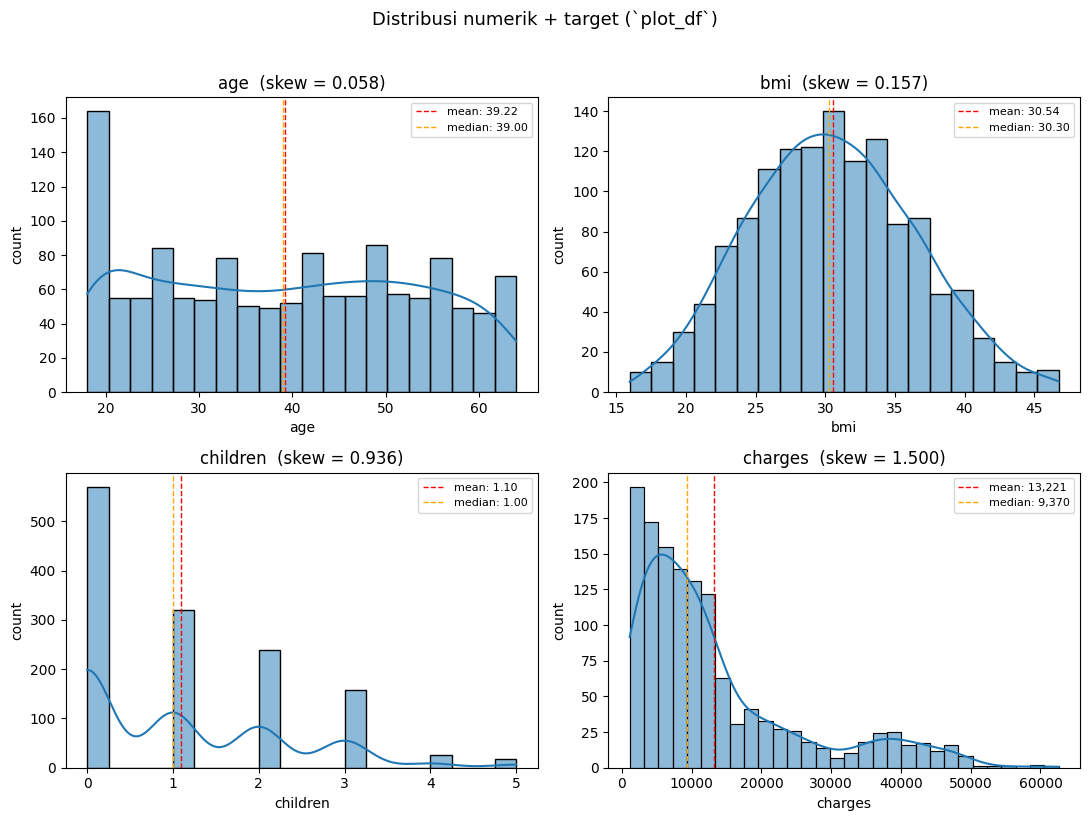

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

skew_cols = ["age", "bmi", "children", "charges"]
skew_summary = (
    pd.DataFrame(
        {
            "skewness": data_df[skew_cols].skew(),
            "mean": data_df[skew_cols].mean(),
            "median": data_df[skew_cols].median(),
        }
    )
    .round(3)
)
print(skew_summary.to_string())

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, skew_cols):
    bins = 30 if col == "charges" else 20
    sns.histplot(data_df[col], kde=True, ax=ax, bins=bins)
    sk = data_df[col].skew()
    mean_v, med_v = data_df[col].mean(), data_df[col].median()
    fmt_mean = f"mean: {mean_v:,.0f}" if col == "charges" else f"mean: {mean_v:.2f}"
    fmt_med = f"median: {med_v:,.0f}" if col == "charges" else f"median: {med_v:.2f}"
    ax.axvline(mean_v, color="red", linestyle="--", linewidth=1, label=fmt_mean)
    ax.axvline(med_v, color="orange", linestyle="--", linewidth=1, label=fmt_med)
    ax.set_title(f"{col}  (skew = {sk:.3f})")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Distribusi numerik + target (`data_df`)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 2. Inferential Statistics

### 2.1 Normality Test

In [667]:
from scipy import stats

stat, p = stats.shapiro(data_df['charges'])
print(f"Shapiro-Wilk: stat={stat:.4f}, p-value={p:.6f}")
print(f"Skewness: {data_df['charges'].skew():.2f}")

Shapiro-Wilk: stat=0.8164, p-value=0.000000
Skewness: 1.50


Because `charges` are strongly right-skewed (skewness ≈ 1.50 on `plot_df`; see the skewness discussion above) and the Shapiro–Wilk test rejects normality (p < 0.05), we use non-parametric tests for group comparisons involving `charges`.

### 2.2 Binary Features VS Charges (Mann-Whitney U Test)

In [668]:
from scipy.stats import mannwhitneyu

for col in ['smoker_encoded', 'gender_encoded']:
    group_0 = data_df[data_df[col] == 0]['charges']
    group_1 = data_df[data_df[col] == 1]['charges']
    stat, p = mannwhitneyu(group_0, group_1, alternative='two-sided')
    print(f"{col}: U={stat:.2f}, p-value={p:.6f} --> {'Significant' if p < 0.05 else 'Not Significant'}")

smoker_encoded: U=7403.00, p-value=0.000000 --> Significant
gender_encoded: U=224121.00, p-value=0.597941 --> Not Significant


### 2.3 Multi-group Features vs Charges (Kruskal-Wallis Test)

In [669]:
from scipy.stats import kruskal

# Region
data_df['region_label'] = data_df[['region_northwest','region_southeast','region_southwest']].idxmax(axis=1)
data_df.loc[(data_df[['region_northwest','region_southeast','region_southwest']].sum(axis=1) == 0), 'region_label'] = 'region_northeast'

region_groups = [group['charges'].values for name, group in data_df.groupby('region_label')]
stat_r, p_r = kruskal(*region_groups)
print(f"region: H={stat_r:.2f}, p-value={p_r:.6f} --> {'Significant' if p_r < 0.05 else 'Not Significant'}")

# Children
children_groups = [group['charges'].values for name, group in data_df.groupby('children')]
stat_c, p_c = kruskal(*children_groups)
print(f"children: H={stat_c:.2f}, p-value={p_c:.6f} --> {'Significant' if p_c < 0.05 else 'Not Significant'}")

data_df = data_df.drop(columns=['region_label'])

region: H=4.89, p-value=0.180366 --> Not Significant
children: H=28.98, p-value=0.000023 --> Significant


### 2.4 Continuous Features vs Charges (Spearman Correlation)

In [670]:
from scipy.stats import spearmanr

for col in ['age', 'bmi']:
    corr, p = spearmanr(data_df[col], data_df['charges'])
    print(f"{col}: rho={corr:.4f}, p-value={p:.6f} --> {'Significant' if p < 0.05 else 'Not Significant'}")

age: rho=0.5345, p-value=0.000000 --> Significant
bmi: rho=0.1188, p-value=0.000014 --> Significant


### Inferential Statistics Summary

| Feature | Test | Statistic | p-value | Result |
|---------|------|-----------|---------|--------|
| smoker | Mann-Whitney U | U = 7,403.00 | 0.000000 | **Significant** |
| gender | Mann-Whitney U | U = 224,121.00 | 0.597941 | Not Significant |
| region | Kruskal-Wallis | H = 4.89 | 0.180366 | Not Significant |
| children | Kruskal-Wallis | H = 28.98 | 0.000023 | **Significant** |
| age | Spearman | rho = 0.5345 | 0.000000 | **Significant** (moderate +) |
| bmi | Spearman | rho = 0.1188 | 0.000014 | **Significant** (weak +) |

**Key Findings:**
- **Smoker** is the strongest predictor of charges by far (extremely low p-value)
- **Age** has a moderate positive correlation with charges; older individuals tend to have higher costs
- **Children** has a significant effect; the number of dependents influences insurance costs
- **BMI** has a weak but statistically significant positive correlation with charges
- **Gender** and **Region** have no significant effect on charges

## 3. Correlation

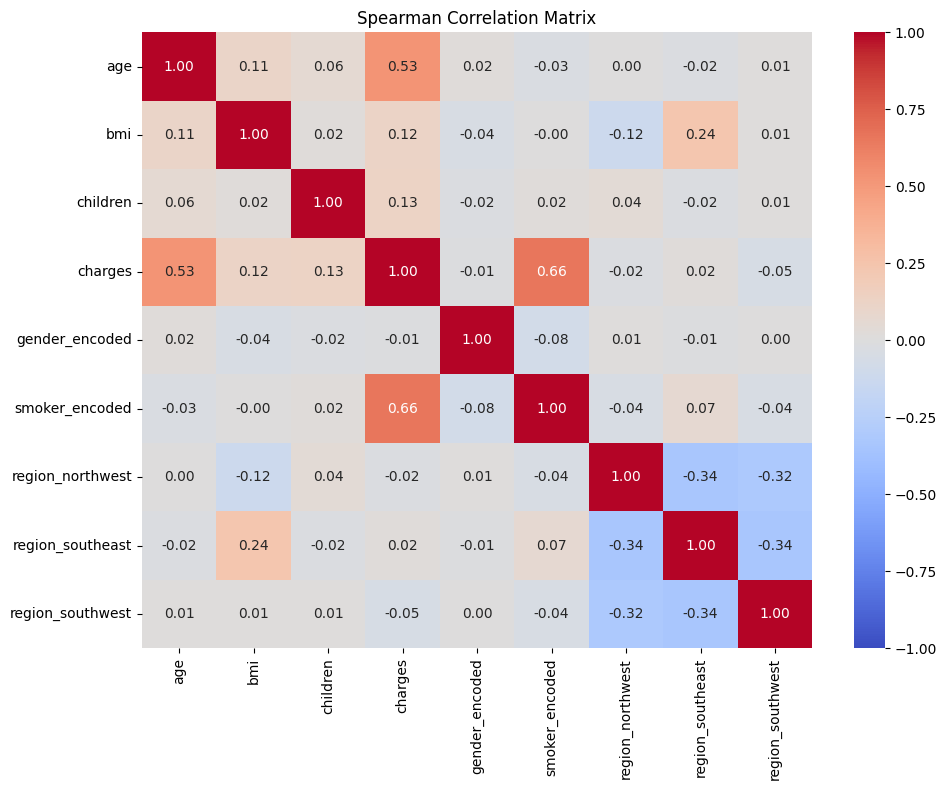

In [671]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = data_df.corr(method='spearman').round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

In [672]:
charges_corr = corr_matrix['charges'].drop('charges').sort_values(ascending=False)
print("Correlation with charges (Spearman):\n")
print(charges_corr.to_string())

Correlation with charges (Spearman):

smoker_encoded      0.66
age                 0.53
children            0.13
bmi                 0.12
region_southeast    0.02
gender_encoded     -0.01
region_northwest   -0.02
region_southwest   -0.05


### Permutation importance

measures how much \(R^2\) drops on average when each feature is shuffled; larger drops indicate features the model relies on more for predicting `charges`. This complements Spearman correlation because it captures **nonlinear** and **joint** effects.


Permutation importance (drop in R² when feature is shuffled):

                  importance_mean  importance_std
smoker_encoded             1.5029          0.0585
bmi                        0.3720          0.0177
age                        0.3182          0.0123
children                   0.0689          0.0055
region_northwest           0.0127          0.0014
region_southeast           0.0125          0.0009
gender_encoded             0.0106          0.0006
region_southwest           0.0101          0.0013


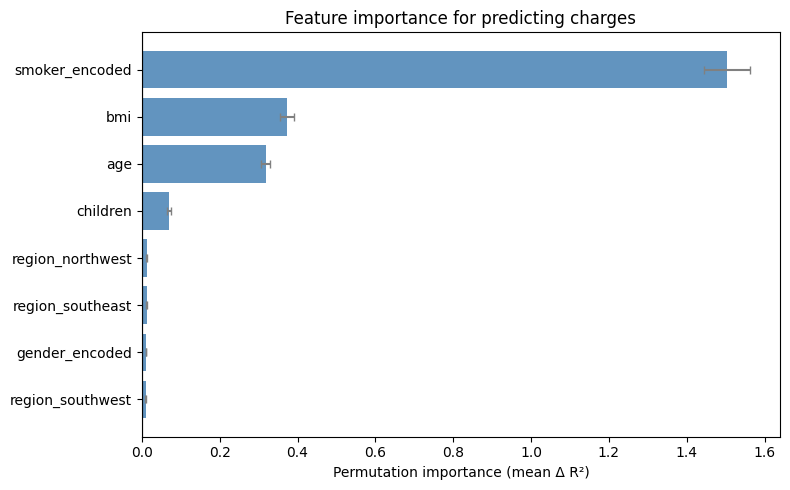

In [673]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

feature_cols = [c for c in data_df.columns if c != "charges"]
X = data_df[feature_cols]
y = data_df["charges"]

rf_pi = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_pi.fit(X, y)

perm = permutation_importance(
    rf_pi,
    X,
    y,
    n_repeats=15,
    random_state=42,
    n_jobs=-1,
    scoring="r2",
)

imp_tbl = (
    pd.DataFrame(
        {
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        },
        index=feature_cols,
    )
    .sort_values("importance_mean", ascending=False)
)
print("Permutation importance (drop in R² when feature is shuffled):\n")
print(imp_tbl.round(4).to_string())

order = np.argsort(perm.importances_mean)
labels = np.array(feature_cols)[order]
means = perm.importances_mean[order]
stds = perm.importances_std[order]

plt.figure(figsize=(8, 5))
plt.barh(labels, means, xerr=stds, capsize=3, color="steelblue", ecolor="gray", alpha=0.85)
plt.xlabel("Permutation importance (mean Δ R²)")
plt.title("Feature importance for predicting charges")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


# Data Visualization

In [674]:
print(f"plot_df: {len(plot_df)} samples (cleaned, with original columns: {list(plot_df.columns)})")

plot_df: 1328 samples (cleaned, with original columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'])


## 1. Distribution

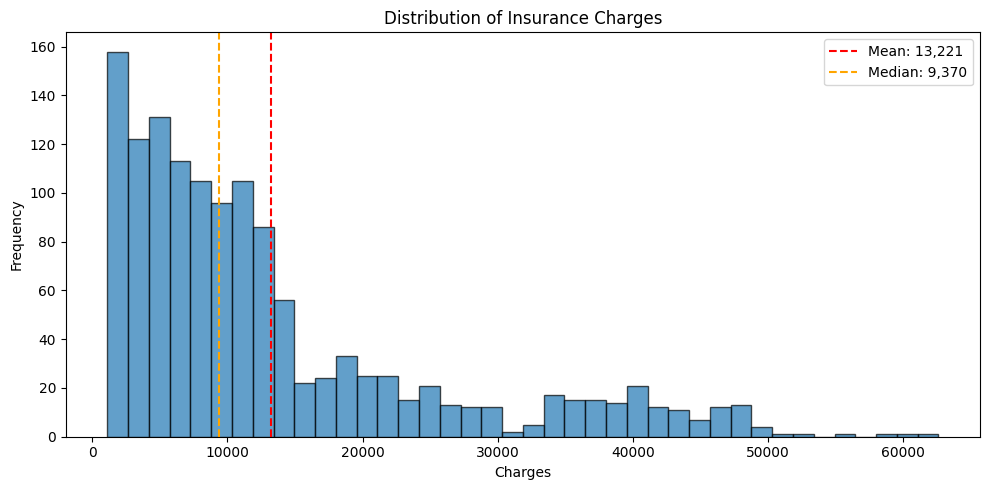

In [675]:
plt.figure(figsize=(10, 5))
plt.hist(plot_df['charges'], bins=40, edgecolor='black', alpha=0.7)
plt.axvline(plot_df['charges'].mean(), color='red', linestyle='--', label=f"Mean: {plot_df['charges'].mean():,.0f}")
plt.axvline(plot_df['charges'].median(), color='orange', linestyle='--', label=f"Median: {plot_df['charges'].median():,.0f}")
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()

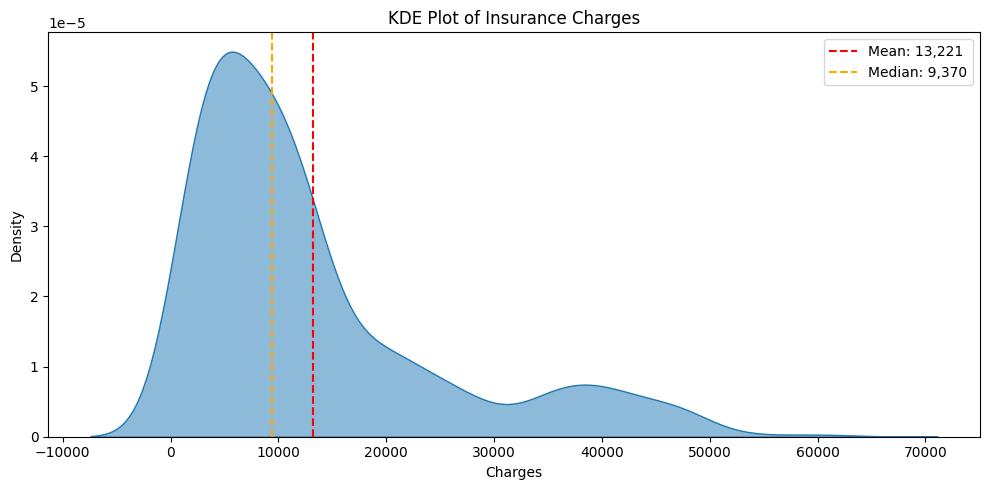

In [676]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=plot_df, x='charges', fill=True, alpha=0.5)

plt.axvline(plot_df['charges'].mean(), color='red', linestyle='--', label=f"Mean: {plot_df['charges'].mean():,.0f}")
plt.axvline(plot_df['charges'].median(), color='orange', linestyle='--', label=f"Median: {plot_df['charges'].median():,.0f}")

plt.xlabel('Charges')
plt.ylabel('Density')
plt.title('KDE Plot of Insurance Charges')
plt.legend()

plt.tight_layout()
plt.show()

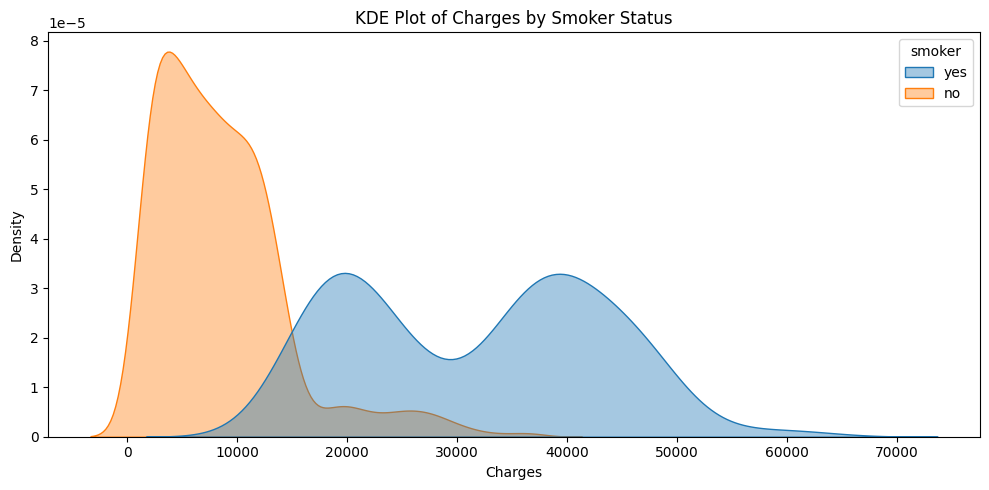

In [677]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=plot_df, x='charges', hue='smoker', fill=True, alpha=0.4, common_norm=False)

plt.xlabel('Charges')
plt.ylabel('Density')
plt.title('KDE Plot of Charges by Smoker Status')

plt.tight_layout()
plt.show()

**Key Findings**

Smokers have higher insurance premiums than non-smokers.

The distribution of charges is right-skewed, with the mean higher than the median, indicating the presence of high-value outliers. The majority of the data falls within the low to mid-range range, while a small percentage has very large charges that skew the average.

In [678]:
numeric_cols = [
    'age',
    'bmi',
    'children'
]

categorical_cols = ['sex', 'smoker', 'region']

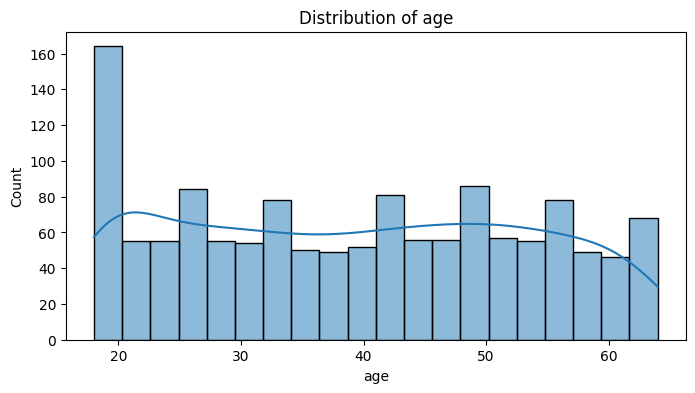

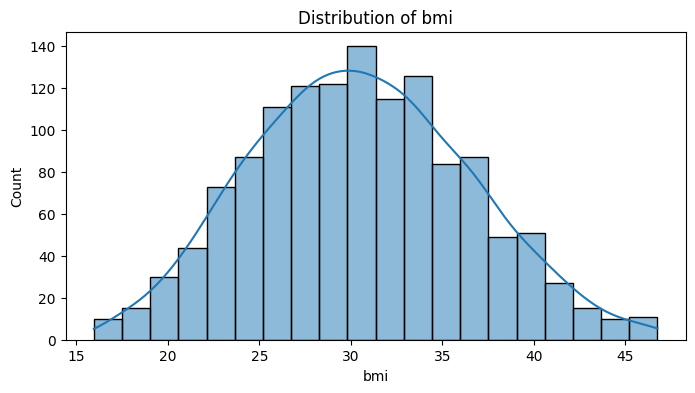

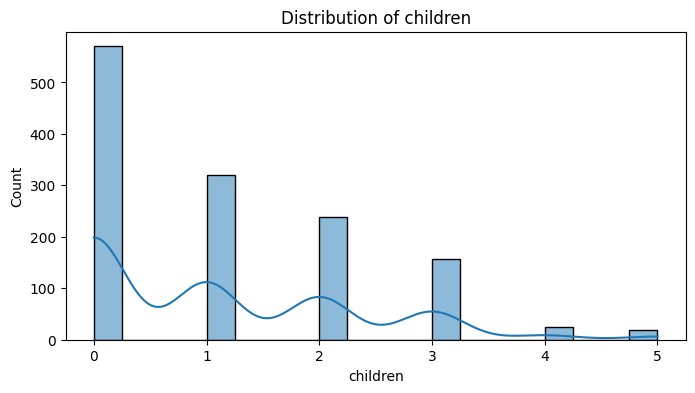

In [679]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(plot_df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

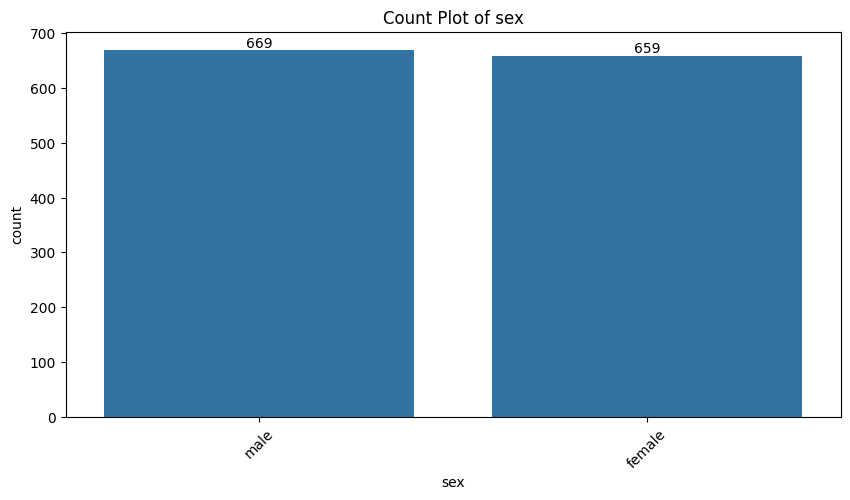

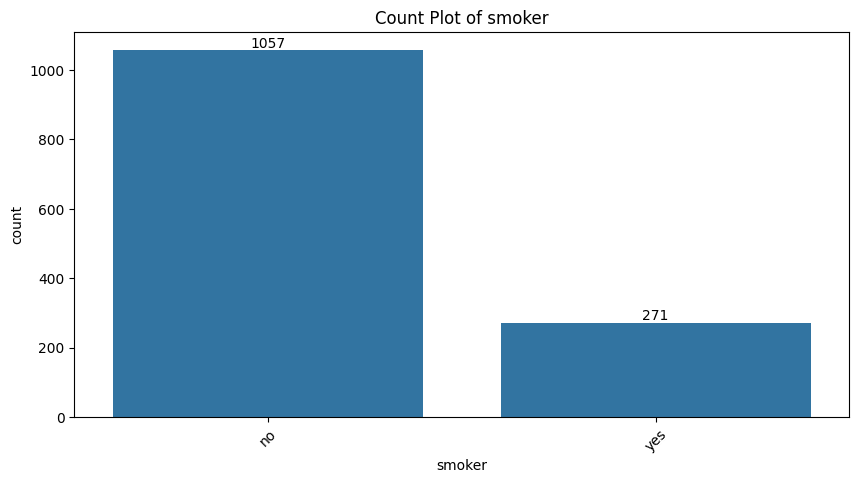

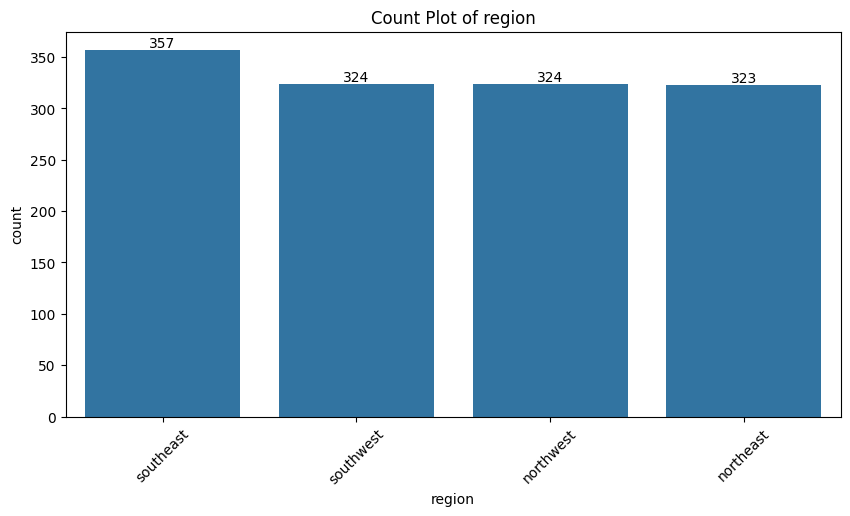

In [680]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=plot_df, x=col, order=plot_df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    
    for container in ax.containers:
        ax.bar_label(container)
    
    plt.show()

## 2. Charges by Smoker

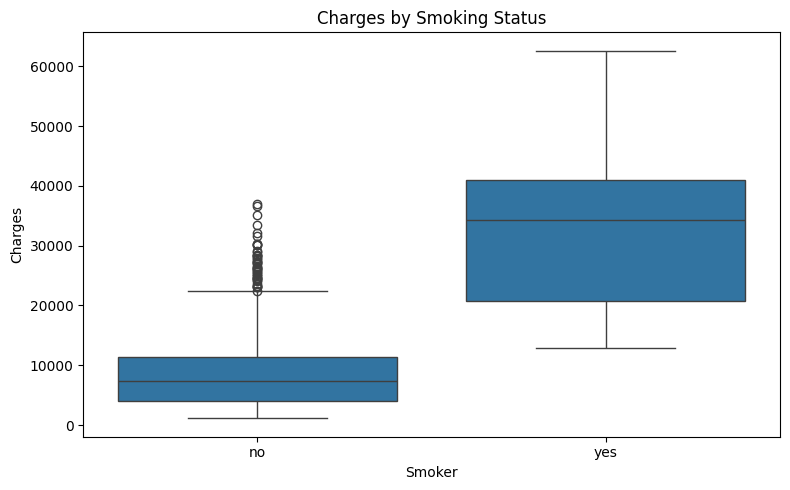

In [681]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='smoker', y='charges', order=['no', 'yes'])
plt.title('Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

## 3. Age vs Charges

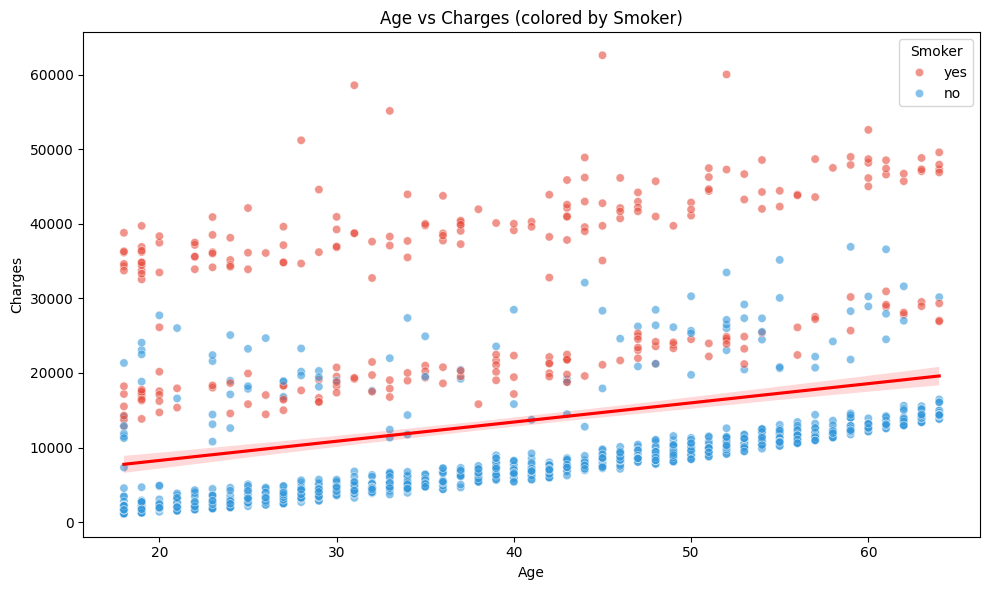

In [682]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='age', y='charges', hue='smoker', alpha=0.6, palette={'no': '#3498db', 'yes': '#e74c3c'})
sns.regplot(data=plot_df, x='age', y='charges', scatter=False, color='red')
plt.title('Age vs Charges (colored by Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

## 4. BMI vs Charges

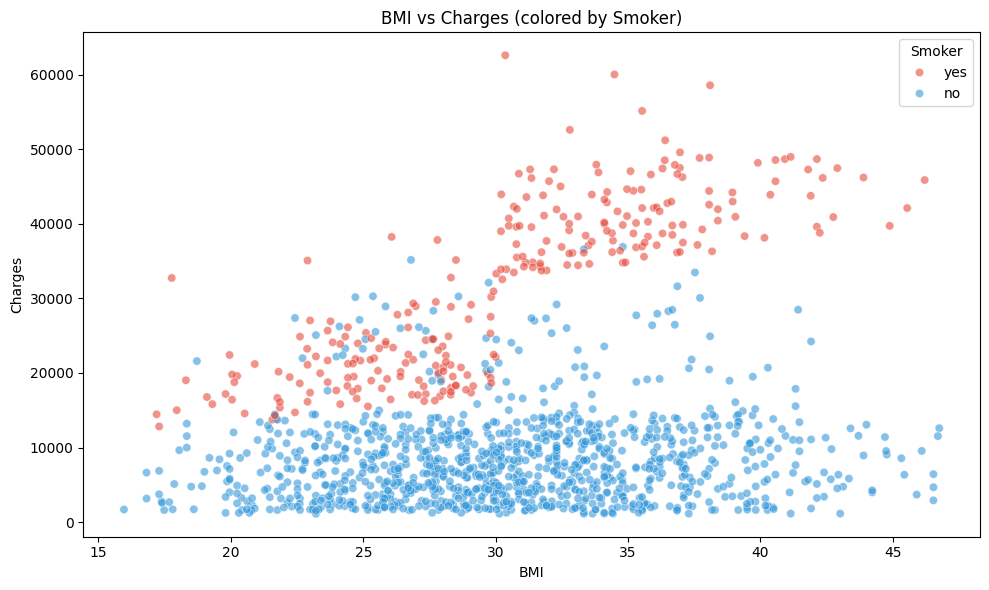

In [683]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='bmi', y='charges', hue='smoker', alpha=0.6, palette={'no': '#3498db', 'yes': '#e74c3c'})
plt.title('BMI vs Charges (colored by Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

## 5. Charges by Children

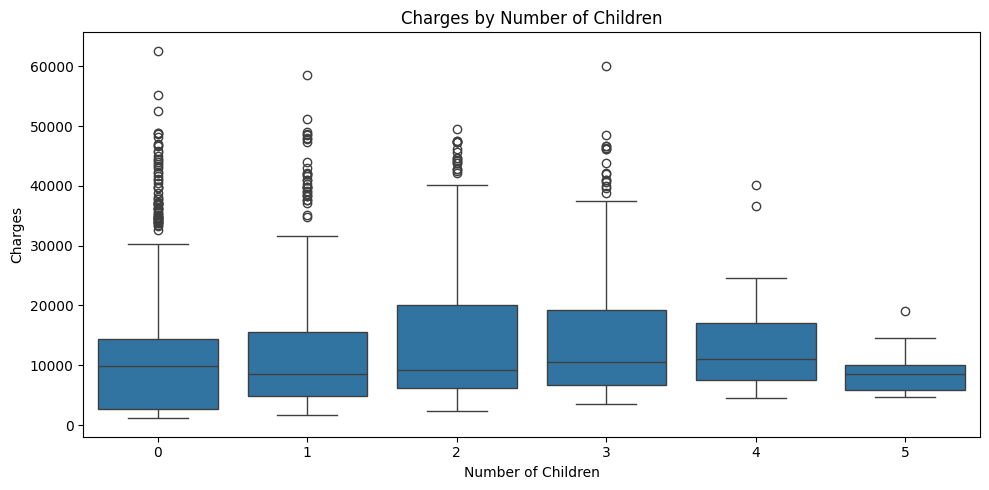

In [684]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x='children', y='charges', order=sorted(plot_df['children'].unique()))
plt.title('Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

## 6. Charges by Gender and Region

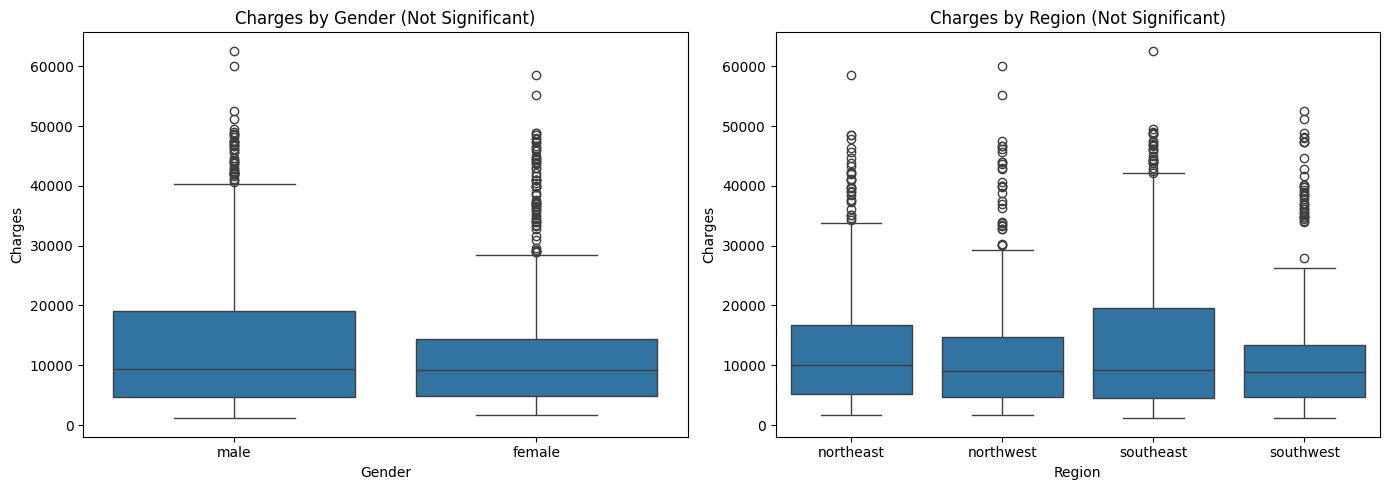

In [685]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x='sex', y='charges', order=['male', 'female'], ax=axes[0])
axes[0].set_title('Charges by Gender (Not Significant)')
axes[0].set_xlabel('Gender') 
axes[0].set_ylabel('Charges')

sns.boxplot(data=plot_df, x='region', y='charges', order=['northeast', 'northwest', 'southeast', 'southwest'], ax=axes[1])
axes[1].set_title('Charges by Region (Not Significant)')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Charges')

plt.tight_layout()
plt.show()

In [686]:
data_df.to_csv("data_cleaned.csv", index=False)
print(f"Saved {len(data_df)} rows, {len(data_df.columns)} columns to data_cleaned.csv")
print(f"Columns: {list(data_df.columns)}")

Saved 1328 rows, 9 columns to data_cleaned.csv
Columns: ['age', 'bmi', 'children', 'charges', 'gender_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']
